## Script to plot the wavelet spectrum of nino3.4 SST anomalies
### For Meg's ENSO paper

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import pywt
from scipy.fft import fft, fftfreq
from scipy.signal import correlate
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.colors as mcolors



from datetime import datetime, timedelta

import sys
sys.path.append("/glade/work/rneale/git/python-scripts/enso")

import  enso_quick_look_utils as enso_ql

import importlib

In [2]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [3]:
cluster = NCARCluster(project='P93300642',interface='ext',walltime="12:00:00")
cluster
cluster.scale(jobs=32)
client = Client(cluster)
client

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/apps/opt/con

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/34127/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/34127/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.194:35623,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/34127/status,Total threads: 0
Started: Just now,Total memory: 0 B



** 1. Grabbing Case Data **
OBS
  - Grabbing  HADISST  data for TS
cesm3
b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.199 /glade/derecho/scratch/rneale/enso_wavelet/ 1 40
  - Timeseries files exist for the case - so I am using them
      /glade/derecho/scratch/rneale/enso_wavelet/b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.199.cam.h0a.TS.1-40.10.N-10.S.nc
{'long_name': 'time', 'bounds': 'time_bounds'}
  - Grabbing  HADISST  data for TS
b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.199 /glade/derecho/scratch/rneale/enso_wavelet/ 1 40
  - Timeseries files exist for the case - so I am using them
      /glade/derecho/scratch/rneale/enso_wavelet/b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.199.cam.h0a.TS.1-40.10.N-10.S.nc
{'long_name': 'time', 'bounds': 'time_bounds'}


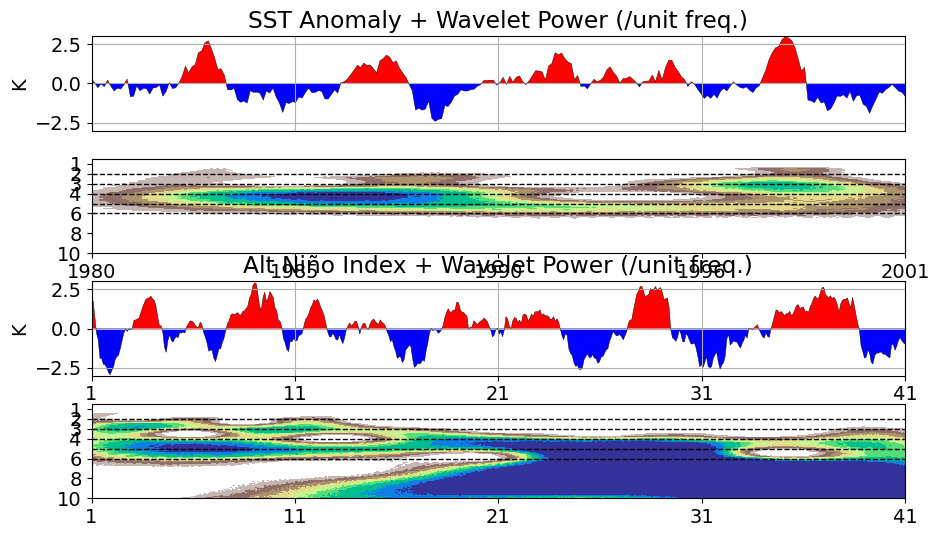

In [13]:
importlib.reload(enso_ql)
dir_fig = '/glade/u/home/rneale/python/python-figs/enso/'

# Simulated Niño3.4 data if you don't have it
#np.random.seed(0)
#n_months = 12 * 50  # 50 years of monthly data
#nino34 = np.random.normal(0, 1, n_months) + np.sin(np.linspace(0, 30 * 2*np.pi, n_months))

# 1. Grab data for x-axis and y-axis variable (obs. or model)

print('')
print('** 1. Grabbing Case Data **')

# Some manipulation because of obs. could be different types ('cases').

var_in = 'TS'

#run_name = 'ERA5' ; run_type = 'OBS' ; year_start = 1950 ; year_stop = 2021
#run_name = 'HADISST' ; run_type = 'OBS' ; year_start = 1979 ; year_stop = 2021

#run_name = 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 135
#run_name = 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.158'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 68
#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.187';run_type = 'cesm3' ; year_start = 1 ; year_stop = 77
#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.181'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 44
#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.188'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 100
run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.199'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 40
#run_name = 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.160'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 100
#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.180'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 44

#run_name = 'b.e11.B1850C5CN.f09_g16.005'; run_type = 'cesm1' ; year_start = 401 ; year_stop = 499
#run_name = 'CESM2_piControl'; run_type = 'cmip6' ; year_start = 401 ; year_stop = 499 # This is the CMIP6 PI control used to initialize the LENS2.

#run_name = '20180129.DECKv1b_piControl.FV1_oEC.edison' ; run_type = 'e3smv1' ; year_start = 401 ; year_stop = 499
#run_name = 'v2.FV1.piControl' ; run_type = 'e3smv2' ; year_start = 401 ; year_stop = 499
#run_name = 'v3.LR.piControl'  ; run_type = 'e3smv3' ; year_start = 401 ; year_stop = 499

ax_frac = 20/80.

lread_in_all_hist = False # Only read a subet of output data, else read all available data in.
lwrite_ts_file = True
lread_ts_file = True

# Example cases
run_cases = [('HADISST','OBS'),
            ('b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.199','cesm3'),
            ]


cases = [("nino34", "SST Anomaly", (1980, 2000)),
    ("nino34", "Alt Niño Index", (1, 40)),
    # (region, label, (start_year, end_year))
]





# ----------------------------
# First pass: figure out max time span

time_spans = []
#icase = -1

for icase, (nino_reg, label, (ystart, ystop)) in enumerate(run_cases):

    run_name = run_cases[icase][0]
    run_type = run_cases[icase][1]

    print(run_type)
    
    da_sst = enso_ql.get_dataset(
        run_name, run_type, var_in, ystart, ystop,
        lread_in_all_hist, lwrite_ts_file, lread_ts_file
    )
    year_float = da_sst.time.dt.year + (da_sst.time.dt.dayofyear - 1) / 365
    time_spans.append((np.min(year_float), np.max(year_float)))

tmin_global = min(lo for lo, hi in time_spans)
tmax_global = max(hi for lo, hi in time_spans)

# Use the first case as the 100% reference span (inclusive-year convention)
ref_start, ref_end = time_spans[0]
ref_len = (ref_end - ref_start)    # +1 for inclusive-year convention (1-100 -> 100)

# ----------------------------
# Setup figure
fig = plt.figure(figsize=(10.5, 3 * len(cases)))  # height grows with cases
plt.rcParams.update({'font.size': 14})

gs = gridspec.GridSpec(nrows=2 * len(cases), ncols=1, hspace=0.3)


# ----------------------------
# Loop over cases (replace inside your existing loop)
for i, (nino_reg, label, (ystart, ystop)) in enumerate(cases):
    run_name = run_cases[i][0]
    run_type = run_cases[i][1]

    # load dataset as before
    da_sst = enso_ql.get_dataset(run_name, run_type, var_in, ystart, ystop,
                                 lread_in_all_hist, lwrite_ts_file, lread_ts_file)
    year_float = da_sst.time.dt.year + (da_sst.time.dt.dayofyear - 1) / 365.0
    nino_ts = enso_ql.nino_anom_ts(da_sst, nino_reg)

    # ---- compute this case's normalized x positions ----
    case_start = float(year_float.min())
    case_end   = float(year_float.max())
    case_len   = (case_end - case_start) + 1.0   # inclusive-year style

    # fraction of the reference axis the case should occupy
    frac = case_len / ref_len if ref_len > 0 else 1.0
    # guard against degenerate single-timepoint case
    if (case_end - case_start) > 0:
        t_norm = ((year_float - case_start) / (case_end - case_start)) * frac
    else:
        # single-timepoint -> spread across tiny interval [0, frac]
        t_norm = np.linspace(0.0, frac, len(year_float))

    # ----------------------------
    # Time series (use t_norm so start=0, end=frac)
    ax1 = fig.add_subplot(gs[2*i, :])
    ax1.plot(t_norm, nino_ts, color='black', linewidth=0.3)
    ax1.fill_between(t_norm, nino_ts, 0, where=nino_ts > 0, facecolor='red', interpolate=True)
    ax1.fill_between(t_norm, nino_ts, 0, where=nino_ts < 0, facecolor='blue', interpolate=True)
    ax1.set_ylim([-3., 3.])
    ax1.set_xlim(0, 1)    # full axis is always 0..1; case data occupies 0..frac
    ax1.set_ylabel("K")
    ax1.set_title(f"{label} + Wavelet Power (/unit freq.)")
    ax1.grid(True)
    if i < len(cases) - 1:
        ax1.tick_params(labelbottom=False, bottom=False)

    # ----------------------------
    # Wavelet (use same normalized t_norm)
    ax2 = fig.add_subplot(gs[2*i+1, :], sharex=ax1)
    wavelet = 'cmor1.5-1.0'
    scales = np.arange(1, 512)
    coeffs, freqs = pywt.cwt(nino_ts, scales, wavelet, sampling_period=1)
    periods = 1. / (12. * freqs)
    power = np.abs(coeffs) ** 2
    
    levels = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14]
    cmap = plt.get_cmap('terrain_r', len(levels) - 1)
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
    
    ax2.pcolormesh(t_norm, periods, power, shading='nearest', cmap=cmap, norm=norm)
    # draw horizontal period lines only across the data region (0..frac)
    for ii in [2, 3, 4, 5, 6]:
        ax2.hlines(ii, 0., frac, colors='black', linestyles='--', lw=1)

    ax2.set_ylim(0.5, 10)
    ax2.set_yticks([1, 2, 3, 4, 6, 8, 10])
    ax2.set_yticklabels([1, 2, 3, 4, 6, 8, 10])
    ax2.invert_yaxis()
    ax2.set_xlim(0, 1)

    # ----------------------------
    # optional: show absolute-year tick labels *only over the data region*
    # (here we put 5 ticks across the data fraction)
    n_ticks = 5

    if frac > 0:
    # ticks along the occupied fraction [0, frac]
        ticks_frac = np.linspace(0.0, frac, n_ticks)
    
        # corresponding absolute years
        tick_years = np.linspace(case_start, case_end, n_ticks)
    
        ax2.set_xticks(ticks_frac.tolist())   # convert to plain Python list
        ax2.set_xticklabels([f"{int(round(y))}" for y in tick_years.tolist()])
    else:
        # single-timepoint case
        ax2.set_xticks([0.0])
        ax2.set_xticklabels([f"{int(round(case_start))}"])


#plt.suptitle(run_name, fontweight='bold', fontsize=14)



fig.savefig(dir_fig+run_name+'_'+var_in+'_'+str(year_start)+'-'+str(year_stop)+'_quick_look.png')
plt.show()